In [1]:
# Install required packages
!pip install -q anthropic google-generativeai requests

In [1]:
import os
import re
from datetime import datetime
import pandas as pd

# ========================================
# CHOOSE YOUR PROVIDER AND PASTE API KEY
# ========================================
PROVIDER = "gemini"  # Options: "claude" or "gemini"

CLAUDE_API_KEY = "YOUR_CLAUDE_KEY_HERE"  # Get from: https://console.anthropic.com/
GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]  # Get from: https://aistudio.google.com/app/apikey

# ========================================

# Setup based on provider
if PROVIDER == "claude":
    import anthropic
    client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)
    print("✅ Using Claude (Anthropic)")
    print("   Model: claude-3-haiku-20240307")
    
elif PROVIDER == "gemini":
    import google.generativeai as genai
    genai.configure(api_key=GEMINI_API_KEY)
    client = genai.GenerativeModel('models/gemini-3-flash-preview')
    #client = genai.GenerativeModel('models/gemini-2.5-flash')
    print("✅ Using Gemini")
    print("   ⚠️  Note: Only 20 requests/day on free tier")


✅ Using Gemini
   ⚠️  Note: Only 20 requests/day on free tier


c:\Users\jettg\miniconda3\envs\ece285\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\jettg\AppData\Local\Temp\ipykernel_12984\37607176.py:24: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [3]:
df = pd.read_csv('wtbdata_245days.csv')

In [23]:
import numpy as np
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_llm_forecast_48h(df, Turb_ID, base_day, output):
    """
    Evaluates a 48-hour (288 point) forecast.
    Always compares against Day base_day+14 and base_day+15.
    """

    # 1. Define 48-hour target window
    target_start = base_day + 14
    target_end = base_day + 15

    # 2. Extract actual data (chronological order)
    actual_data = df[
        (df['TurbID'] == Turb_ID) &
        (df['Day'] >= target_start) &
        (df['Day'] <= target_end)
    ]

    actual_values = (
        actual_data
        .sort_values(['Day', 'Tmstamp'])
        ['Patv']
        .dropna()
        .tolist()
    )

    # 3. Robust parsing of LLM output
    try:
        predicted_values = [
            float(x) for x in re.findall(r"[-+]?\d*\.\d+|\d+", output)
        ]
    except Exception:
        print("Error: Could not parse LLM output.")
        return None

    # 4. Check expected length (288 points)
    if len(predicted_values) != 288:
        print(f"Warning: Expected 288 predictions, got {len(predicted_values)}")

    if len(actual_values) != 288:
        print(f"Warning: Expected 288 actual points, got {len(actual_values)}")

    # 5. Align lengths safely
    min_len = min(len(actual_values), len(predicted_values))

    if min_len == 0:
        print("Error: No overlapping forecast points.")
        return None

    y_true = actual_values[:min_len]
    y_pred = predicted_values[:min_len]

    # 6. Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = (mae + rmse) /2

    print(f"\n--- 48-Hour Evaluation (Days {target_start}-{target_end}) ---")
    print(f"Points used: {min_len}/288")
    print(f"MAE:  {mae:.2f} kW")
    print(f"RMSE: {rmse:.2f} kW")
    print(f"Score: {score:.2f} kW")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Score": score,
        "points_used": min_len
    }

# Baseline Prompt

In [2]:
import pandas as pd

def call_llm_base(df, Turb_ID, base_day):
    turbine_data = df[df['TurbID'] == Turb_ID]
    # Drop rows where 'Wspd' (Wind Speed) is missing
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    end_day = base_day + 13
    window_data = turbine_data[(turbine_data['Day'] >= base_day) & 
                               (turbine_data['Day'] <= end_day)].drop(columns=['TurbID'])

    data_str = window_data.to_csv(index=False, sep=',')

    prompt = f"""
You have been provided with 14 days of sensor data for one Wind Turbine, starting from day {base_day} to day {end_day}. 

Input Data (last 14 days):
{data_str}

Task: Predict the 'Patv' (Active Power) for the NEXT 48 hours (Day {end_day + 2}). Do not write code. Return only a list containing exactly 288 numerical values (144 per day), representing 10-minute intervals.
"""
    
    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    else:  # gemini
        response = client.generate_content(prompt)
        return response.text

In [4]:
response = call_llm_base(df, Turb_ID=1, base_day=1)

In [10]:
print("LLM Response:" , response)
eval = evaluate_llm_forecast_48h(df, Turb_ID=1, base_day=1, output=response)



LLM Response: <output>
[490.5, 502.1, 515.8, 528.4, 510.2, 495.7, 480.3, 475.9, 488.2, 501.5, 520.8, 545.1, 560.4, 582.7, 605.1, 622.8, 650.3, 675.9, 702.4, 730.1, 755.8, 782.3, 810.7, 835.2, 860.9, 890.4, 915.2, 940.8, 965.3, 990.1, 1015.7, 1040.2, 1070.8, 1100.4, 1130.1, 1165.7, 1200.2, 1230.8, 1265.4, 1300.1, 1335.7, 1370.2, 1405.8, 1440.4, 1470.1, 1495.7, 1515.2, 1530.8, 1540.4, 1548.1, 1549.7, 1550.2, 1550.5, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1550.4, 1550.2, 1550.1, 1548.5, 1540.2, 1530.8, 1515.1, 1490.4, 1460.7, 1430.2, 1400.8, 1370.1, 1340.7, 1310.2, 1280.8, 1250.1, 1220.7, 1190.2, 1160.8, 1130.1, 1100.7, 1070.2, 1040.8, 1010.1, 980.7, 950.2, 920.8, 890.1, 860.7, 830.2, 800.8, 770.1, 740.7, 710.2, 

## Simple prompting is not ENOUGH

In [ ]:
def call_llm1(df, Turb_ID, base_day):
    turbine_data = df[df['TurbID'] == Turb_ID]
    # Drop rows where 'Wspd' (Wind Speed) is missing
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    end_day = base_day + 13
    window_data = turbine_data[(turbine_data['Day'] >= base_day) & 
                               (turbine_data['Day'] <= end_day)].drop(columns=['TurbID'])

    data_str = window_data.to_csv(index=False, sep=',')

    prompt = f"""
Context: You are a energy forecaster for wind turbines. You have been provided with 14 days of sensor data for Wind Turbine {Turb_ID}, starting from day {base_day} to day {end_day}. 
The data is sampled every 10 minutes (144 rows total).

Columns: Tmstamp (time stamp), Wspd (wind speed in m/s), Wdir (The angle between the wind direction and the position of turbine nacelle in degrees), Etmp (Temperature of the surounding environment in celcius), Itmp (Temperature inside the turbine nacelle in celcius), Ndir (Nacelle direction, i.e., the yaw angle of the nacelle in degrees), Pab1 (Pitch angle of blade 1 in degrees), Pab2 (Pitch angle of blade 2 in degrees), Pab3 (Pitch angle of blade 3 in degrees), Prtv (Reactive power in kW), Patv (Active power in kW)

Input Data (last 14 days):
{data_str}

Task: Based on the historical patterns in the 14-day window provided, predict the 'Patv' (Active Power) for the NEXT 48 hours (Days {end_day + 1} and {end_day + 2}). Do not write code. Analyze the relationship between wind speed, temperature, and power in the provided data, and output your best estimate for the next 48 hours based on these trends. Return only a list containing exactly 288 numerical values (144 per day), representing 10-minute intervals.
"""
    
    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    else:  # gemini
        response = client.generate_content(
            prompt,
            generation_config={
                "temperature": 0.2,
                "max_output_tokens": 3000
            }
        )
        return response.text

# SPACE TOKENIZATION

In [11]:
df = pd.read_csv('wtbdata_245days.csv')
feature_sets = {
    #"current_best_features": ["Wspd", "Etmp", "Itmp", "Patv"],
    #"wind_only": ["Wspd", "Patv"],
    #"wind_direction": ["Wspd", "Wdir", "Patv"],
    #"wind_temp": ["Wspd", "Etmp", "Patv"],
    #"wind_nacelle": ["Wspd", "Ndir", "Patv"],
    #"wind_pitch (team 7)": ["Wspd", "Pab1", "Pab2", "Pab3", "Patv"],
    #"all_physical": ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", "Patv"],
    "all_features (Teams 1-6)": ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", 
                     "Pab1", "Pab2", "Pab3", "Prtv", "Patv"]
}



In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_forecast_metrics(y_true, y_pred):
    """Calculates accuracy metrics for the forecast."""
    # Ensure they are the same length
    min_len = min(len(y_true), len(y_pred))
    y_t = y_true[:min_len]
    y_p = y_pred[:min_len]
    
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae = mean_absolute_error(y_t, y_p)
    score = (rmse + mae) / 2
    
    return {"RMSE": rmse, "MAE": mae, "Score": score}

In [17]:
def call_llm_advanced(df, Turb_ID, base_day, feature_cols):
    turbine_data = df[df['TurbID'] == Turb_ID]
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    end_day = base_day + 13

    # Always keep timestamp for ordering
    required_cols = ['Day', 'Tmstamp'] + feature_cols

    window_data = turbine_data[
        (turbine_data['Day'] >= base_day) & 
        (turbine_data['Day'] <= end_day)
    ][required_cols].copy()


    data_str = window_data.to_csv(index=False, sep=',')

    prompt = f"""
Context: You are an expert wind turbine power forecasting model.

You are given 14 days of historical SCADA data for ONE turbine.
The data is sampled every 10 minutes (144 rows per day).
Columns provided: {', '.join(required_cols)}

Input Data:
{data_str}

Your task:
Predict the Active Power (Patv, in kW) for the NEXT 48 HOURS
(288 time steps at 10-minute resolution).

Instructions:

Learn the wind-speed to power relationship from the historical data.
Power is roughly proportional to wind speed cubed at low speeds.
Power saturates near rated power (~1500 kW).
Power is near zero at very low wind speeds.

Capture daily cyclic patterns.
Do NOT copy the last day.
Do NOT output negative values.
Clip values to the realistic range [0, 1500].

OUTPUT FORMAT REQUIREMENTS (CRITICAL):

Return valid JSON in the following format:

{{
  "forecast": [f1, f2, f3, ..., f288]
}}

The list MUST contain exactly 288 numbers.
If the list contains more or fewer values, the answer is invalid.

No text outside the JSON.
No explanations.
No markdown formatting.
Only raw JSON.
"""

    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    else:  # gemini
        response = client.generate_content(
            prompt
        )
        return response.text

In [20]:
def call_llm_space(df, Turb_ID, end_day, feature_cols):
    turbine_data = df[df['TurbID'] == Turb_ID]
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    base_day = end_day - 13

    # Always keep timestamp for ordering
    required_cols = ['Day', 'Tmstamp'] + feature_cols

    window_data = turbine_data[
        (turbine_data['Day'] >= base_day) & 
        (turbine_data['Day'] <= end_day)
    ][required_cols].copy()

    # 1. Tokenize the digits inside the columns
    for col in required_cols:
        window_data[col] = window_data[col].astype(str).apply(lambda x: " ".join(list(x)))

    # 2. Use " , " (space-comma-space) as the separator
    # This ensures every value is separated from the comma by a space
    temp_data_str = window_data.to_csv(index=False, sep='|')

    data_str = temp_data_str.replace('|', ' , ')

    prompt = f"""
Context: You are an expert wind turbine power forecasting model.

You are given 14 days of historical SCADA data for ONE turbine.
The data is sampled every 10 minutes (144 rows per day).
Columns provided: {', '.join(required_cols)}

Input Data:
{data_str}

Your task:
Predict the Active Power (Patv, in kW) for the NEXT 48 HOURS
(288 time steps at 10-minute resolution).

Instructions:

Learn the wind-speed to power relationship from the historical data.
Power is roughly proportional to wind speed cubed at low speeds.
Power saturates near rated power (~1500 kW).
Power is near zero at very low wind speeds.

Capture daily cyclic patterns.
Do NOT copy the last day.
Do NOT output negative values.
Clip values to the realistic range [0, 1500].

OUTPUT FORMAT REQUIREMENTS (CRITICAL):

Return valid JSON in the following format:

{{
  "forecast": [f1, f2, f3, ..., f288]
}}

The list MUST contain exactly 288 numbers.
If the list contains more or fewer values, the answer is invalid.

No text outside the JSON.
No explanations.
No markdown formatting.
Only raw JSON.
"""

    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    else:  # gemini
        response = client.generate_content(
            prompt
        )
        return response.text

In [31]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_llm_predictions_vs_ground_truth(
    data_df: pd.DataFrame,    # Pass the actual DataFrame here
    llm_responses,           # List of raw string responses from the LLM
    turb_id: int,
    forecast_day: int,
    horizon_days: int = 2,
    labels=None,
    title=None,
    clip=(0.0, 1500.0),
    hour_tick: float = 2.0,
    legend_alpha: float = 0.75,
    show=True,
):
    # --- 1. Handle Inputs ---
    if labels is None:
        labels = [f"LLM Prediction {i+1}" for i in range(len(llm_responses))]
    
    # --- 2. Ground Truth Extraction ---
    expected_len = 144 * horizon_days
    target_days = list(range(forecast_day, forecast_day + horizon_days))
    
    gt = data_df[(data_df["TurbID"] == turb_id) & (data_df["Day"].isin(target_days))].copy()
    if gt.empty:
        raise ValueError(f"No ground-truth found for TurbID {turb_id} on days {target_days}")

    gt = gt.sort_values(["Day", "Tmstamp"]) if "Tmstamp" in gt.columns else gt.sort_values(["Day"])
    
    y_true = gt["Patv"].to_numpy(dtype=float)
    if len(y_true) < expected_len:
         # Pad or truncate if data is slightly off, but warn user
         print(f"Warning: GT length {len(y_true)} vs expected {expected_len}")
    
    y_true = np.clip(y_true[:expected_len], clip[0], clip[1])

    # --- 3. Setup Plot ---
    x_hours = np.arange(len(y_true)) / 6.0
    fig, ax = plt.subplots(figsize=(12.5, 5))
    ax.plot(x_hours, y_true, linewidth=2.0, label="Ground truth", color='tab:blue')

    # --- 4. Parse and Plot LLM Responses ---
    for raw_response, lab in zip(llm_responses, labels):
        try:
            # Clean up potential markdown formatting
            clean_json = raw_response.replace("```json", "").replace("```", "").strip()
            data = json.loads(clean_json)
            y_pred = np.array(data["forecast"], dtype=float)
            
            if len(y_pred) != expected_len:
                print(f"Warning: {lab} returned {len(y_pred)} steps, expected {expected_len}")
            
            # Ensure length matches x_hours for plotting
            plot_len = min(len(y_pred), len(x_hours))
            y_pred_clipped = np.clip(y_pred[:plot_len], clip[0], clip[1])
            
            ax.plot(x_hours[:plot_len], y_pred_clipped, linewidth=1.5, linestyle="--", color="orange", label=lab)
            
        except Exception as e:
            print(f"Error parsing LLM response for {lab}: {e}")

    # --- 5. Formatting ---
    ax.set_xlim(0, 24 * horizon_days)
    ax.set_xticks(np.arange(0, (24 * horizon_days) + 1e-9, hour_tick))
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Patv (kW)")
    ax.grid(True, alpha=0.2)

    if title is None:
        title = f"TurbID={turb_id} | Day {forecast_day} | Horizon = 2 day(s)"
    ax.set_title(title)

    # Update this section in your plotting function
    ax.legend(
        loc="lower left",            # Anchors the legend to its bottom-left corner
        bbox_to_anchor=(0.02, 0.02), # Adds a small padding from the axes corner
        framealpha=legend_alpha,
        fontsize=10,
        borderpad=0.6,
        labelspacing=0.4,
        handlelength=2.2,
    )
    fig.tight_layout()
    
    if show:
        plt.show()
    return fig, ax

In [19]:
# 1. Get the response
response_advanced = call_llm_advanced(df, 1, 19, feature_sets["all_features (Teams 1-6)"])


NameError: name 'call_llm_space' is not defined

In [21]:
response_space = call_llm_space(df, 1, 19, feature_sets["all_features (Teams 1-6)"])

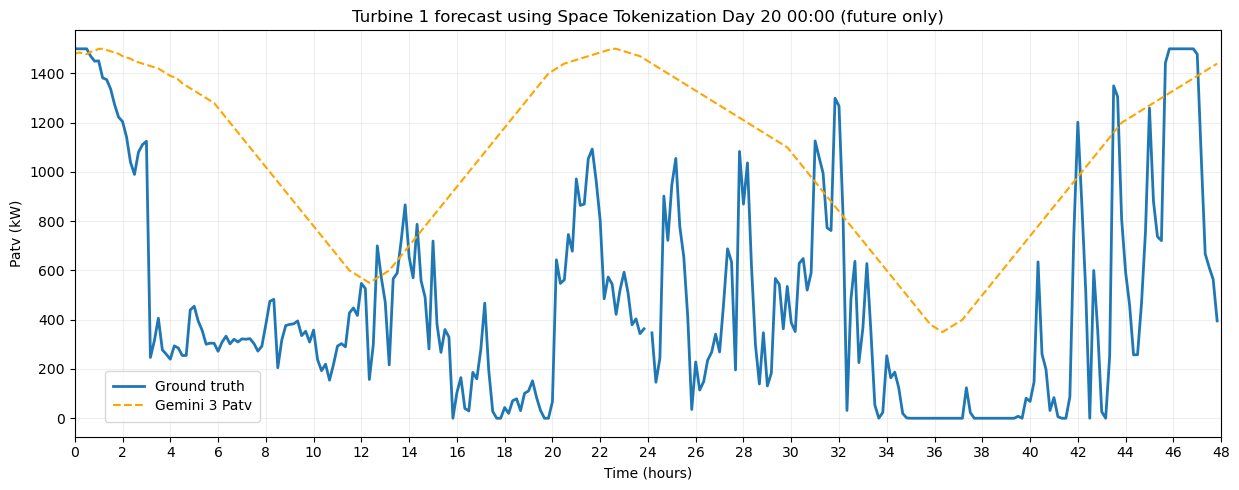

(<Figure size 1250x500 with 1 Axes>,
 <Axes: title={'center': 'Turbine 1 forecast using Space Tokenization Day 20 00:00 (future only)'}, xlabel='Time (hours)', ylabel='Patv (kW)'>)

In [33]:
# 2. Plot it directly
plot_llm_predictions_vs_ground_truth(
    data_df=df, 
    llm_responses=[response_space], 
    labels=["Gemini 3 Patv"],
    turb_id=1, 
    title="Turbine 1 forecast using Space Tokenization Day 20 00:00 (future only)",
    forecast_day=20 # end_day + 1 (start of forecast)
)

In [24]:
eval = evaluate_llm_forecast_48h(df, 1, 6, response_space)


--- 48-Hour Evaluation (Days 20-21) ---
Points used: 287/288
MAE:  608.36 kW
RMSE: 702.65 kW
Score: 655.51 kW


# JUNK

In [5]:
df = pd.read_csv('wtbdata_245days.csv')
feature_sets = {
    #"current_best_features": ["Wspd", "Etmp", "Itmp", "Patv"],
    #"wind_only": ["Wspd", "Patv"],
    #"wind_direction": ["Wspd", "Wdir", "Patv"],
    #"wind_temp": ["Wspd", "Etmp", "Patv"],
    #"wind_nacelle": ["Wspd", "Ndir", "Patv"],
    #"wind_pitch (team 7)": ["Wspd", "Pab1", "Pab2", "Pab3", "Patv"],
    #"all_physical": ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", "Patv"],
    "all_features (Teams 1-6)": ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", 
                     "Pab1", "Pab2", "Pab3", "Prtv", "Patv"]
}



In [ ]:
def test_space_tokenization(df, Turb_ID, base_day, feature_cols):
    turbine_data = df[df['TurbID'] == Turb_ID]
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    end_day = base_day + 13

    # Always keep timestamp for ordering
    required_cols = ['Day', 'Tmstamp'] + feature_cols

    window_data = turbine_data[
        (turbine_data['Day'] >= base_day) & 
        (turbine_data['Day'] <= end_day)
    ][required_cols].copy()

    # SPACE TOKENIZATION START
    # 1. Tokenize the digits inside the columns
    for col in required_cols:
        window_data[col] = window_data[col].astype(str).apply(lambda x: " ".join(list(x)))

    # 2. Use " , " (space-comma-space) as the separator
    # This ensures every value is separated from the comma by a space
    temp_data_str = window_data.to_csv(index=False, sep='|')

    fin_data_str = temp_data_str.replace('|', ' , ')

    return fin_data_str

In [6]:
import numpy as np
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_llm_forecast_48h(df, Turb_ID, base_day, output):
    """
    Evaluates a 48-hour (288 point) forecast.
    Always compares against Day base_day+14 and base_day+15.
    """

    # 1. Define 48-hour target window
    target_start = base_day + 14
    target_end = base_day + 15

    # 2. Extract actual data (chronological order)
    actual_data = df[
        (df['TurbID'] == Turb_ID) &
        (df['Day'] >= target_start) &
        (df['Day'] <= target_end)
    ]

    actual_values = (
        actual_data
        .sort_values(['Day', 'Tmstamp'])
        ['Patv']
        .dropna()
        .tolist()
    )

    # 3. Robust parsing of LLM output
    try:
        predicted_values = [
            float(x) for x in re.findall(r"[-+]?\d*\.\d+|\d+", output)
        ]
    except Exception:
        print("Error: Could not parse LLM output.")
        return None

    # 4. Check expected length (288 points)
    if len(predicted_values) != 288:
        print(f"Warning: Expected 288 predictions, got {len(predicted_values)}")

    if len(actual_values) != 288:
        print(f"Warning: Expected 288 actual points, got {len(actual_values)}")

    # 5. Align lengths safely
    min_len = min(len(actual_values), len(predicted_values))

    if min_len == 0:
        print("Error: No overlapping forecast points.")
        return None

    y_true = actual_values[:min_len]
    y_pred = predicted_values[:min_len]

    # 6. Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = (mae + rmse) /2

    print(f"\n--- 48-Hour Evaluation (Days {target_start}-{target_end}) ---")
    print(f"Points used: {min_len}/288")
    print(f"MAE:  {mae:.2f} kW")
    print(f"RMSE: {rmse:.2f} kW")
    print(f"Score: {score:.2f} kW")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Score": score,
        "points_used": min_len
    }

In [27]:
output = test_space_tokenization(df, Turb_ID=1, base_day=3, feature_cols=feature_sets["all_features (Teams 1-6)"])


In [28]:
print(output)

Day , Tmstamp , Wspd , Wdir , Etmp , Itmp , Ndir , Pab1 , Pab2 , Pab3 , Prtv , Patv
3 , 0 0 : 0 0 , 1 1 . 4 5 , - 2 . 1 6 , 2 6 . 8 4 , 4 0 . 2 8 , 7 . 4 2 , 1 . 0 5 , 1 . 0 5 , 1 . 0 5 , - 0 . 1 8 , 1 5 4 9 . 4 5
3 , 0 0 : 1 0 , 1 0 . 9 3 , - 2 . 9 6 , 2 6 . 6 8 , 4 0 . 3 3 , 7 . 4 2 , 1 . 0 3 , 1 . 0 3 , 1 . 0 3 , - 0 . 2 4 , 1 5 2 3 . 6 7
3 , 0 0 : 2 0 , 1 0 . 6 9 , - 4 . 6 1 , 2 6 . 5 5 , 4 0 . 4 , 7 . 4 2 , 1 . 0 1 , 1 . 0 1 , 1 . 0 1 , - 0 . 2 6 , 1 4 9 9 . 0 1
3 , 0 0 : 3 0 , 1 1 . 5 4 , - 4 . 0 8 , 2 6 . 4 5 , 4 0 . 3 4 , 5 . 6 3 , 1 . 0 5 , 1 . 0 5 , 1 . 0 5 , - 0 . 2 7 , 1 5 4 3 . 6 4
3 , 0 0 : 4 0 , 1 0 . 6 3 , 0 . 5 5 , 2 6 . 3 4 , 4 0 . 2 9 , - 0 . 2 7 , 1 . 0 2 , 1 . 0 2 , 1 . 0 2 , - 0 . 2 8 , 1 5 0 4 . 2 3
3 , 0 0 : 5 0 , 1 0 . 8 1 , 3 . 7 5 , 2 6 . 2 7 , 4 0 . 2 , - 0 . 2 7 , 1 . 0 1 , 1 . 0 1 , 1 . 0 1 , - 0 . 2 7 , 1 5 0 0 . 4 5
3 , 0 1 : 0 0 , 1 1 . 4 6 , - 0 . 1 2 , 2 6 . 2 , 4 0 . 2 , 5 . 0 3 , 1 . 0 5 , 1 . 0 5 , 1 . 0 5 , - 0 . 2 3 , 1 5 5 0 . 1 7
3 , 0 1 : 1 0 

In [24]:
import json

# Parse the JSON string returned by the LLM
parsed_output = json.loads(output)

# Extract the forecast list
predicted_values = parsed_output["forecast"]

print("Predicted count:", len(predicted_values))

# Extract actual data
actual_data = df[
    (df['TurbID'] == 1) &
    (df['Day'] >= 3 + 14) &
    (df['Day'] <= 3 + 15)
]

print("Actual count:", len(actual_data))
print("Missing Patv:", actual_data['Patv'].isna().sum())

Predicted count: 288
Actual count: 288
Missing Patv: 0


In [25]:
metrics = evaluate_llm_forecast_48h(
        df,
        Turb_ID=1,
        base_day=3,
        output=output
    )


--- 48-Hour Evaluation (Days 17-18) ---
Points used: 288/288
MAE:  559.38 kW
RMSE: 700.71 kW
Score: 630.05 kW


In [26]:
import time
import numpy as np

results = {}
num_runs = 3  # number of LLM runs per feature set

for name, features in feature_sets.items():
    print(f"\n==============================")
    print(f"Testing feature set: {name}")
    print(f"==============================")

    mae_list = []
    rmse_list = []
    score_list = []

    for run in range(num_runs):
        print(f"\nRun {run+1}/{num_runs} - Calling LLM...")
        
        try:
            output = call_llm_test_features(
                df, Turb_ID=1, base_day=3, feature_cols=features
            )
            print("LLM finished")

            metrics = evaluate_llm_forecast_48h(
                df,
                Turb_ID=1,
                base_day=3,
                output=output
            )

            if metrics:
                mae_list.append(metrics["MAE"])
                rmse_list.append(metrics["RMSE"])
                score_list.append(metrics["Score"])

        except Exception as e:
            print(f"Run failed: {e}")

        time.sleep(2)  # small delay to reduce API stress

    # Compute averages only if we have valid runs
    if len(mae_list) > 0:
        results[name] = {
            "Avg_MAE": np.mean(mae_list),
            "Avg_RMSE": np.mean(rmse_list),
            "Avg_Score": np.mean(score_list),
            "Std_MAE": np.std(mae_list),
            "Std_RMSE": np.std(rmse_list),
            "Std_Score": np.std(score_list),
            "Runs_completed": len(mae_list)
        }

print("\n==============================")
print("Final Averaged Comparison:")
print("==============================")

for name, metrics in results.items():
    print(f"\nFeature Set: {name}")
    print(f"Runs completed: {metrics['Runs_completed']}/3")
    print(f"Average MAE:   {metrics['Avg_MAE']:.2f}")
    print(f"Average RMSE:  {metrics['Avg_RMSE']:.2f}")
    print(f"Average Score: {metrics['Avg_Score']:.2f}")
    print(f"Std Score:     {metrics['Std_Score']:.2f}")


Testing feature set: all_features (Teams 1-6)

Run 1/3 - Calling LLM...
LLM finished

--- 48-Hour Evaluation (Days 17-18) ---
Points used: 288/288
MAE:  566.36 kW
RMSE: 747.33 kW
Score: 656.84 kW

Run 2/3 - Calling LLM...
LLM finished

--- 48-Hour Evaluation (Days 17-18) ---
Points used: 286/288
MAE:  461.89 kW
RMSE: 612.72 kW
Score: 537.31 kW

Run 3/3 - Calling LLM...
LLM finished

--- 48-Hour Evaluation (Days 17-18) ---
Points used: 288/288
MAE:  776.03 kW
RMSE: 933.89 kW
Score: 854.96 kW

Final Averaged Comparison:

Feature Set: all_features (Teams 1-6)
Runs completed: 3/3
Average MAE:   601.43
Average RMSE:  764.65
Average Score: 683.04
Std Score:     131.00


In [16]:
results = {}

for name, features in feature_sets.items():
    print(f"\nTesting feature set: {name}")
    print("Calling LLM...")
    output = call_llm_test_features(df, Turb_ID=1, base_day=3, feature_cols=features)
    print("LLM finished")

    metrics = evaluate_llm_forecast_48h(
        df,
        Turb_ID=1,
        base_day=3,
        output=output
    )

    if metrics:
        results[name] = metrics

print("\nFinal Comparison:")
print(results)


Testing feature set: current_best_features
Calling LLM...
LLM finished

--- 48-Hour Evaluation (Days 17-18) ---
Points used: 288/288
MAE:  599.08 kW
RMSE: 729.94 kW
Score: 664.51 kW

Testing feature set: wind_only
Calling LLM...
LLM finished

--- 48-Hour Evaluation (Days 17-18) ---
Points used: 268/288
MAE:  622.54 kW
RMSE: 777.41 kW
Score: 699.98 kW

Testing feature set: wind_direction
Calling LLM...
LLM finished

--- 48-Hour Evaluation (Days 17-18) ---
Points used: 288/288
MAE:  256.33 kW
RMSE: 303.51 kW
Score: 279.92 kW

Testing feature set: wind_temp
Calling LLM...
LLM finished

--- 48-Hour Evaluation (Days 17-18) ---
Points used: 288/288
MAE:  669.60 kW
RMSE: 834.97 kW
Score: 752.29 kW

Testing feature set: wind_nacelle
Calling LLM...
LLM finished

--- 48-Hour Evaluation (Days 17-18) ---
Points used: 282/288
MAE:  857.80 kW
RMSE: 1009.58 kW
Score: 933.69 kW

Testing feature set: wind_pitch (team 7)
Calling LLM...
LLM finished

--- 48-Hour Evaluation (Days 17-18) ---
Points used: 

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash
Please retry in 26.75042582s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-3-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 26
}
]

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure both lists are the same length
target_day = base_day + 1
actual_data = df[(df['TurbID'] == Turb_ID) & (df['Day'] == target_day)]

actual_values = actual_data['Patv'].dropna().tolist()
predicted_values = [float(val.strip()) for val in output.split(',')]

min_len = min(len(actual_values), len(predicted_values))
y_true = actual_values[:min_len]
y_pred = predicted_values[:min_len]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Mean Absolute Error: {mae:.2f} kW")
print(f"Root Mean Square Error: {rmse:.2f} kW")

Mean Absolute Error: 24.40 kW
Root Mean Square Error: 37.24 kW


144 144


# DEMO

In [ ]:
def call_llm_test_features(df, Turb_ID, base_day, feature_cols):
    turbine_data = df[df['TurbID'] == Turb_ID]
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    end_day = base_day + 13

    # Always keep timestamp for ordering
    required_cols = ['Day', 'Tmstamp'] + feature_cols

    window_data = turbine_data[
        (turbine_data['Day'] >= base_day) & 
        (turbine_data['Day'] <= end_day)
    ][required_cols].copy()

    # 1. Tokenize the digits inside the columns
    for col in required_cols:
        window_data[col] = window_data[col].astype(str).apply(lambda x: " ".join(list(x)))

    # 2. Use " , " (space-comma-space) as the separator
    # This ensures every value is separated from the comma by a space
    temp_data_str = window_data.to_csv(index=False, sep='|')

    data_str = temp_data_str.replace('|', ' , ')

    prompt = f"""
Context: You are an expert wind turbine power forecasting model.

You are given 14 days of historical SCADA data for ONE turbine.
The data is sampled every 10 minutes (144 rows per day).
Columns provided: {', '.join(required_cols)}

Input Data:
{data_str}

Your task:
Predict the Active Power (Patv, in kW) for the NEXT 48 HOURS
(288 time steps at 10-minute resolution).

Instructions:

Learn the wind-speed to power relationship from the historical data.
Power is roughly proportional to wind speed cubed at low speeds.
Power saturates near rated power (~1500 kW).
Power is near zero at very low wind speeds.

Capture daily cyclic patterns.
Do NOT copy the last day.
Do NOT output negative values.
Clip values to the realistic range [0, 1500].

OUTPUT FORMAT REQUIREMENTS (CRITICAL):

Return valid JSON in the following format:

{{
  "forecast": [f1, f2, f3, ..., f288]
}}

The list MUST contain exactly 288 numbers.
If the list contains more or fewer values, the answer is invalid.

No text outside the JSON.
No explanations.
No markdown formatting.
Only raw JSON.
"""

    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    else:  # gemini
        response = client.generate_content(
            prompt
        )
        return response.text

In [ ]:
import numpy as np
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_llm_forecast_48h(df, Turb_ID, base_day, output):
    """
    Evaluates a 48-hour (288 point) forecast.
    Always compares against Day base_day+14 and base_day+15.
    """

    # 1. Define 48-hour target window
    target_start = base_day + 14
    target_end = base_day + 15

    # 2. Extract actual data (chronological order)
    actual_data = df[
        (df['TurbID'] == Turb_ID) &
        (df['Day'] >= target_start) &
        (df['Day'] <= target_end)
    ]

    actual_values = (
        actual_data
        .sort_values(['Day', 'Tmstamp'])
        ['Patv']
        .dropna()
        .tolist()
    )

    # 3. Robust parsing of LLM output
    try:
        predicted_values = [
            float(x) for x in re.findall(r"[-+]?\d*\.\d+|\d+", output)
        ]
    except Exception:
        print("Error: Could not parse LLM output.")
        return None

    # 4. Check expected length (288 points)
    if len(predicted_values) != 288:
        print(f"Warning: Expected 288 predictions, got {len(predicted_values)}")

    if len(actual_values) != 288:
        print(f"Warning: Expected 288 actual points, got {len(actual_values)}")

    # 5. Align lengths safely
    min_len = min(len(actual_values), len(predicted_values))

    if min_len == 0:
        print("Error: No overlapping forecast points.")
        return None

    y_true = actual_values[:min_len]
    y_pred = predicted_values[:min_len]

    # 6. Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = (mae + rmse) /2

    print(f"\n--- 48-Hour Evaluation (Days {target_start}-{target_end}) ---")
    print(f"Points used: {min_len}/288")
    print(f"MAE:  {mae:.2f} kW")
    print(f"RMSE: {rmse:.2f} kW")
    print(f"Score: {score:.2f} kW")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Score": score,
        "points_used": min_len
    }

In [ ]:
df = pd.read_csv('wtbdata_245days.csv')
feature_sets = {
    #"current_best_features": ["Wspd", "Etmp", "Itmp", "Patv"],
    #"wind_only": ["Wspd", "Patv"],
    #"wind_direction": ["Wspd", "Wdir", "Patv"],
    #"wind_temp": ["Wspd", "Etmp", "Patv"],
    #"wind_nacelle": ["Wspd", "Ndir", "Patv"],
    #"wind_pitch (team 7)": ["Wspd", "Pab1", "Pab2", "Pab3", "Patv"],
    #"all_physical": ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", "Patv"],
    "all_features (Teams 1-6)": ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", 
                     "Pab1", "Pab2", "Pab3", "Prtv", "Patv"]
}

